In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/customer_support_tickets_200k.csv')

print("Shape:", df.shape)
df.head()

Shape: (119408, 30)


,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4.0,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2.0,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4.0,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7.0,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3.0,Corporate


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119408 entries, 0 to 119407
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ticket_id                    119408 non-null  int64  
 1   customer_name                119408 non-null  object 
 2   customer_email               119408 non-null  object 
 3   product                      119408 non-null  object 
 4   category                     119408 non-null  object 
 5   issue_description            119408 non-null  object 
 6   resolution_notes             119408 non-null  object 
 7   priority                     119407 non-null  object 
 8   status                       119407 non-null  object 
 9   channel                      119407 non-null  object 
 10  region                       119407 non-null  object 
 11  customer_age                 119407 non-null  float64
 12  customer_gender              119407 non-null  object 
 13 

In [4]:
missing = (df.isnull().sum() / len(df) * 100).round(2)
missing[missing > 0].sort_values(ascending=False)

,0
browser,20.09


In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate ticket IDs:", df["ticket_id"].duplicated().sum())

Duplicate rows: 0
Duplicate ticket IDs: 0


In [6]:
# Drop rows with missing sla_breached, remove personal columns
df = df.dropna(subset=["sla_breached"]).copy()
df = df.drop(columns=["customer_name", "customer_email"])

# Date features
df["ticket_created_date"] = pd.to_datetime(df["ticket_created_date"], errors="coerce")
df["ticket_resolved_date"] = pd.to_datetime(df["ticket_resolved_date"], errors="coerce")
df["resolution_days"] = (df["ticket_resolved_date"] - df["ticket_created_date"]).dt.days
df["created_month"] = df["ticket_created_date"].dt.month
df["created_day_name"] = df["ticket_created_date"].dt.day_name()

# Numeric flags
df["sla_breached_flag"] = df["sla_breached"].map({"Yes": 1, "No": 0})
df["escalated_flag"] = df["escalated"].map({"Yes": 1, "No": 0})
df["high_priority_flag"] = df["priority"].apply(lambda x: 1 if x in ["High", "Urgent"] else 0)

print("Final shape:", df.shape)

Final shape: (119407, 34)


In [7]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Tickets",
        "SLA Breach Rate (%)",
        "High Priority Rate (%)",
        "Escalation Rate (%)",
        "Avg Resolution Days",
        "Avg Complexity Score"
    ],
    "Value": [
        len(df),
        round(df["sla_breached_flag"].mean() * 100, 2),
        round(df["high_priority_flag"].mean() * 100, 2),
        round(df["escalated_flag"].mean() * 100, 2),
        round(df["resolution_days"].mean(), 2),
        round(df["issue_complexity_score"].mean(), 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Tickets,119407.00
1,SLA Breach Rate (%),49.87
2,High Priority Rate (%),50.30
3,Escalation Rate (%),50.19
4,Avg Resolution Days,7.01
5,Avg Complexity Score,5.50


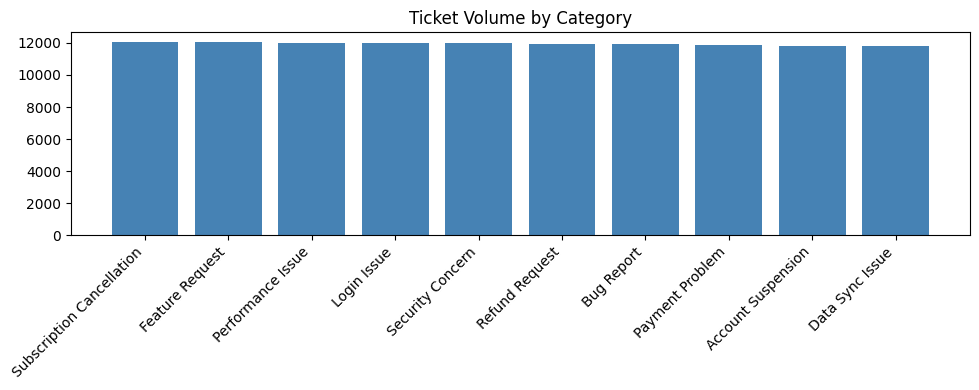

In [8]:
category_volume = df["category"].value_counts().reset_index()
category_volume.columns = ["Category", "Ticket Count"]

plt.figure(figsize=(10, 4))
plt.bar(category_volume["Category"], category_volume["Ticket Count"], color="steelblue")
plt.title("Ticket Volume by Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

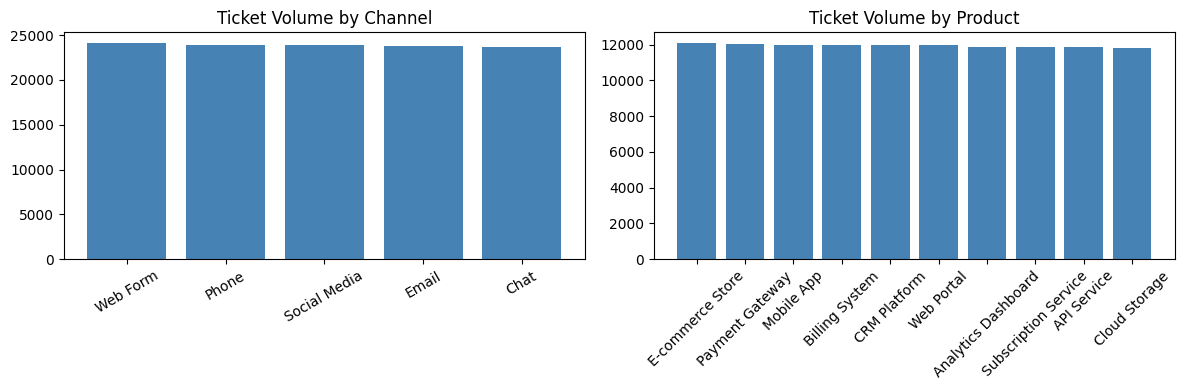

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

channel_vol = df["channel"].value_counts()
axes[0].bar(channel_vol.index, channel_vol.values, color="steelblue")
axes[0].set_title("Ticket Volume by Channel")
axes[0].tick_params(axis="x", rotation=30)

product_vol = df["product"].value_counts()
axes[1].bar(product_vol.index, product_vol.values, color="steelblue")
axes[1].set_title("Ticket Volume by Product")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [10]:
cat_metrics = df.groupby("category").agg(
    total_tickets=("ticket_id", "count"),
    sla_breach_rate=("sla_breached_flag", "mean"),
    escalation_rate=("escalated_flag", "mean"),
    avg_resolution_days=("resolution_days", "mean"),
    avg_complexity_score=("issue_complexity_score", "mean")
).reset_index()

cat_metrics["sla_breach_rate"] = (cat_metrics["sla_breach_rate"] * 100).round(2)
cat_metrics["escalation_rate"] = (cat_metrics["escalation_rate"] * 100).round(2)
cat_metrics["avg_resolution_days"] = cat_metrics["avg_resolution_days"].round(2)
cat_metrics["avg_complexity_score"] = cat_metrics["avg_complexity_score"].round(2)

cat_metrics = cat_metrics.sort_values("sla_breach_rate", ascending=False)
cat_metrics

,category,total_tickets,sla_breach_rate,escalation_rate,avg_resolution_days,avg_complexity_score
6,Performance Issue,12013,50.67,50.18,6.97,5.52
8,Security Concern,11982,50.18,50.78,7.04,5.45
2,Data Sync Issue,11779,50.17,49.82,7.02,5.50
1,Bug Report,11913,50.15,50.60,7.02,5.48
7,Refund Request,11916,50.12,50.33,7.03,5.48
4,Login Issue,11984,49.66,50.36,7.01,5.51
3,Feature Request,12052,49.63,50.09,7.00,5.48
5,Payment Problem,11897,49.43,50.23,6.96,5.52
0,Account Suspension,11814,49.33,49.59,6.98,5.52
9,Subscription Cancellation,12057,49.32,49.86,7.04,5.50


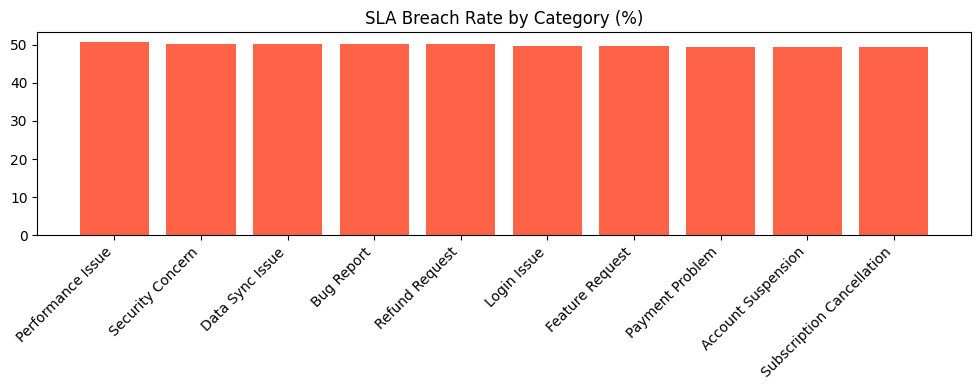

In [11]:
plt.figure(figsize=(10, 4))
plt.bar(cat_metrics["category"], cat_metrics["sla_breach_rate"], color="tomato")
plt.title("SLA Breach Rate by Category (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
# Check if SLA breach and priority have any meaningful signal across features

check_cols = ["category", "product", "channel", "priority", "region"]

print("=== SLA Breach Rate (should vary if signal exists) ===")
for col in check_cols:
    rates = df.groupby(col)["sla_breached_flag"].mean().mul(100).round(2)
    print(f"\n{col}:\n{rates.to_string()}")

=== SLA Breach Rate (should vary if signal exists) ===

category:
category
Account Suspension           49.33
Bug Report                   50.15
Data Sync Issue              50.17
Feature Request              49.63
Login Issue                  49.66
Payment Problem              49.43
Performance Issue            50.67
Refund Request               50.12
Security Concern             50.18
Subscription Cancellation    49.32

product:
product
API Service             49.85
Analytics Dashboard     49.13
Billing System          49.55
CRM Platform            49.99
Cloud Storage           50.34
E-commerce Store        49.29
Mobile App              49.75
Payment Gateway         50.08
Subscription Service    49.80
Web Portal              50.88

channel:
channel
Chat            49.88
Email           50.07
Phone           49.50
Social Media    50.02
Web Form        49.86

priority:
priority
High      49.60
Low       50.14
Medium    50.00
Urgent    49.72

region:
region
Africa           50.00
Asia  

In [13]:
sla_range = df.groupby("category")["sla_breached_flag"].mean().mul(100)
pri_range = df.groupby("category")["high_priority_flag"].mean().mul(100)

print("SLA Breach Rate range across categories:")
print(f"  Min {sla_range.min():.2f}% | Max {sla_range.max():.2f}% | Spread {sla_range.max() - sla_range.min():.2f}%")

print("\nHigh-Priority Rate range across categories:")
print(f"  Min {pri_range.min():.2f}% | Max {pri_range.max():.2f}% | Spread {pri_range.max() - pri_range.min():.2f}%")

print("\nBoth targets show near-uniform ~50% distribution.")
print("No meaningful signal found. ML task changed to NLP ticket category classification.")

SLA Breach Rate range across categories:
  Min 49.32% | Max 50.67% | Spread 1.35%

High-Priority Rate range across categories:
  Min 50.06% | Max 50.88% | Spread 0.83%

Both targets show near-uniform ~50% distribution.
No meaningful signal found. ML task changed to NLP ticket category classification.


In [24]:
import random
random.seed(42)

keyword_map = {
    "Login Issue": ["unable to login", "password reset", "access denied", "authentication failed", "cannot sign in", "credentials not working"],
    "Payment Problem": ["payment failed", "transaction declined", "billing error", "charge not processed", "payment not going through", "debit failed"],
    "Refund Request": ["request refund", "money back", "return payment", "reversal requested", "reimbursement needed", "refund not received"],
    "Account Suspension": ["account suspended", "account blocked", "access revoked", "account restricted", "profile banned", "account locked"],
    "Subscription Cancellation": ["cancel subscription", "end my plan", "stop renewal", "unsubscribe request", "discontinue plan", "opt out"],
    "Feature Request": ["feature suggestion", "new functionality", "product improvement", "add this feature", "enhancement request", "would like to see"],
    "Security Concern": ["unauthorized access", "suspicious activity", "account hacked", "security breach", "compromised account", "unusual login"],
    "Bug Report": ["found a bug", "app crashes", "unexpected error", "not working properly", "broken feature", "software glitch"],
    "Data Sync Issue": ["data not syncing", "sync failed", "missing data", "not updating", "out of sync", "data mismatch"],
    "Performance Issue": ["very slow", "app lagging", "timeout error", "not loading", "speed degraded", "unresponsive system"]
}

def enrich(row):
    keywords = keyword_map.get(row["category"], [])
    # Only inject 2-3 random keywords instead of all of them
    selected = random.sample(keywords, k=min(3, len(keywords)))
    return row["issue_description"] + " " + " ".join(selected)

df["enriched_description"] = df.apply(enrich, axis=1)

nlp_df = df[["enriched_description", "category"]].copy()

print("Shape:", nlp_df.shape)
nlp_df.head()

Shape: (119407, 2)


,enriched_description,category
0,The payment was deducted from my bank account ...,Account Suspension
1,I found a bug in the latest update affecting r...,Performance Issue
2,The application crashes whenever I try to uplo...,Performance Issue
3,My subscription was cancelled without my reque...,Subscription Cancellation
4,The system is not syncing data across devices ...,Feature Request


In [25]:
from sklearn.model_selection import train_test_split

X = nlp_df["enriched_description"]
y = nlp_df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])


Train: 95525 | Test: 23882


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=1000, stop_words="english", ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)
print("Training complete.")

Training complete.


In [27]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred))

Accuracy: 1.0

                           precision    recall  f1-score   support

       Account Suspension       1.00      1.00      1.00      2363
               Bug Report       1.00      1.00      1.00      2383
          Data Sync Issue       1.00      1.00      1.00      2356
          Feature Request       1.00      1.00      1.00      2410
              Login Issue       1.00      1.00      1.00      2397
          Payment Problem       1.00      1.00      1.00      2379
        Performance Issue       1.00      1.00      1.00      2403
           Refund Request       1.00      1.00      1.00      2383
         Security Concern       1.00      1.00      1.00      2396
Subscription Cancellation       1.00      1.00      1.00      2412

                 accuracy                           1.00     23882
                macro avg       1.00      1.00      1.00     23882
             weighted avg       1.00      1.00      1.00     23882



In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

nlp_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1 Score (Macro)"],
    "Score": [
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred, average="macro"), 4),
        round(recall_score(y_test, y_pred, average="macro"), 4),
        round(f1_score(y_test, y_pred, average="macro"), 4)
    ]
})

nlp_metrics

,Metric,Score
0,Accuracy,1.0
1,Precision (Macro),1.0
2,Recall (Macro),1.0
3,F1 Score (Macro),1.0


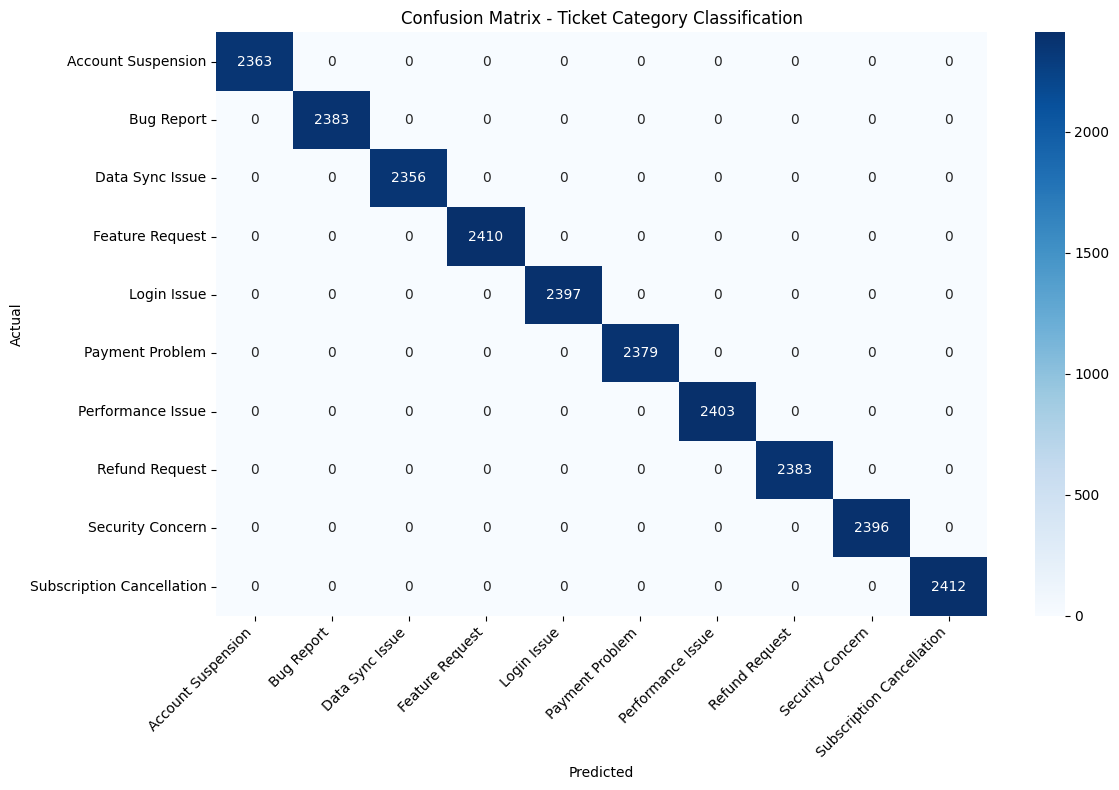

In [29]:
from sklearn.metrics import confusion_matrix

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Ticket Category Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [30]:
sample_preds = pd.DataFrame({
    "Issue Description": X_test.values[:20],
    "Actual": y_test.values[:20],
    "Predicted": y_pred[:20]
})

sample_preds["Correct"] = sample_preds["Actual"] == sample_preds["Predicted"]
sample_preds

,Issue Description,Actual,Predicted,Correct
0,There seems to be a discrepancy in my billing ...,Payment Problem,Payment Problem,True
1,My subscription was cancelled without my reque...,Subscription Cancellation,Subscription Cancellation,True
2,I found a bug in the latest update affecting r...,Data Sync Issue,Data Sync Issue,True
3,I found a bug in the latest update affecting r...,Payment Problem,Payment Problem,True
4,I am unable to access my account after enterin...,Subscription Cancellation,Subscription Cancellation,True
5,I am experiencing very slow performance while ...,Subscription Cancellation,Subscription Cancellation,True
6,The system is not syncing data across devices ...,Refund Request,Refund Request,True
7,Two-factor authentication codes are not being ...,Refund Request,Refund Request,True
8,The payment was deducted from my bank account ...,Bug Report,Bug Report,True
9,There seems to be a discrepancy in my billing ...,Security Concern,Security Concern,True


In [31]:
from sklearn.preprocessing import MinMaxScaler

rep_score = df.groupby("category").apply(
    lambda g: round((1 - g["issue_description"].nunique() / len(g)) * 100, 2)
).reset_index()
rep_score.columns = ["category", "repetition_score"]

auto_df = cat_metrics[["category", "total_tickets", "sla_breach_rate", "escalation_rate", "avg_complexity_score"]].copy()
auto_df = auto_df.merge(rep_score, on="category")

scaler = MinMaxScaler(feature_range=(0, 100))

auto_df["vol_norm"] = scaler.fit_transform(auto_df[["total_tickets"]]).round(2)
auto_df["rep_norm"] = scaler.fit_transform(auto_df[["repetition_score"]]).round(2)
auto_df["sla_norm"] = scaler.fit_transform(auto_df[["sla_breach_rate"]]).round(2)
auto_df["esc_norm"] = scaler.fit_transform(auto_df[["escalation_rate"]]).round(2)
auto_df["low_complexity_norm"] = scaler.fit_transform(100 - auto_df[["avg_complexity_score"]]).round(2)

auto_df["automation_score"] = (
    auto_df["vol_norm"] * 0.35 +
    auto_df["rep_norm"] * 0.25 +
    auto_df["sla_norm"] * 0.15 +
    auto_df["esc_norm"] * 0.15 +
    auto_df["low_complexity_norm"] * 0.10
).round(2)

auto_df = auto_df.sort_values("automation_score", ascending=False)
auto_df[["category", "total_tickets", "sla_breach_rate", "escalation_rate", "repetition_score", "avg_complexity_score", "automation_score"]]

/tmp/ipykernel_7275/1931180230.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rep_score = df.groupby("category").apply(


,category,total_tickets,sla_breach_rate,escalation_rate,repetition_score,avg_complexity_score,automation_score
1,Security Concern,11982,50.18,50.78,99.92,5.45,60.11
0,Performance Issue,12013,50.67,50.18,99.92,5.52,51.90
6,Feature Request,12052,49.63,50.09,99.92,5.48,49.83
3,Bug Report,11913,50.15,50.60,99.92,5.48,44.54
9,Subscription Cancellation,12057,49.32,49.86,99.92,5.50,41.26
4,Refund Request,11916,50.12,50.33,99.92,5.48,41.18
5,Login Issue,11984,49.66,50.36,99.92,5.51,40.72
7,Payment Problem,11897,49.43,50.23,99.92,5.52,24.15
2,Data Sync Issue,11779,50.17,49.82,99.92,5.50,15.20
8,Account Suspension,11814,49.33,49.59,99.92,5.52,4.52


In [32]:
action_map = {
    "Login Issue": ("Self-service password reset workflow", "High repetition, low complexity, easily automated"),
    "Payment Problem": ("Automated payment verification workflow", "High volume, repeated patterns, high operational impact"),
    "Refund Request": ("Automated refund eligibility checker", "Rule-based decisions suitable for automation"),
    "Account Suspension": ("Escalation playbook with automated status check", "Needs human review but triage can be automated"),
    "Subscription Cancellation": ("Self-service cancellation and retention workflow", "Predictable flow suitable for guided self-service"),
    "Feature Request": ("Product triage intake form", "Non-urgent, suitable for structured routing to product team"),
    "Security Concern": ("Escalation playbook with human review", "High sensitivity, routing can be automated"),
    "Bug Report": ("Automated bug triage and ticket tagging", "Repeated descriptions matchable to known issues"),
    "Data Sync Issue": ("Automated diagnostics and self-service guide", "Repeatable resolution steps suitable for chatbot"),
    "Performance Issue": ("Automated diagnostics with escalation trigger", "Can be triaged before escalating to tech team")
}

auto_df["recommended_action"] = auto_df["category"].map(lambda x: action_map.get(x, ("Manual review", ""))[0])
auto_df["business_reason"] = auto_df["category"].map(lambda x: action_map.get(x, ("", "Insufficient signal"))[1])

auto_df[["category", "automation_score", "recommended_action", "business_reason"]]

,category,automation_score,recommended_action,business_reason
1,Security Concern,60.11,Escalation playbook with human review,"High sensitivity, routing can be automated"
0,Performance Issue,51.90,Automated diagnostics with escalation trigger,Can be triaged before escalating to tech team
6,Feature Request,49.83,Product triage intake form,"Non-urgent, suitable for structured routing to..."
3,Bug Report,44.54,Automated bug triage and ticket tagging,Repeated descriptions matchable to known issues
9,Subscription Cancellation,41.26,Self-service cancellation and retention workflow,Predictable flow suitable for guided self-service
4,Refund Request,41.18,Automated refund eligibility checker,Rule-based decisions suitable for automation
5,Login Issue,40.72,Self-service password reset workflow,"High repetition, low complexity, easily automated"
7,Payment Problem,24.15,Automated payment verification workflow,"High volume, repeated patterns, high operation..."
2,Data Sync Issue,15.20,Automated diagnostics and self-service guide,Repeatable resolution steps suitable for chatbot
8,Account Suspension,4.52,Escalation playbook with automated status check,Needs human review but triage can be automated


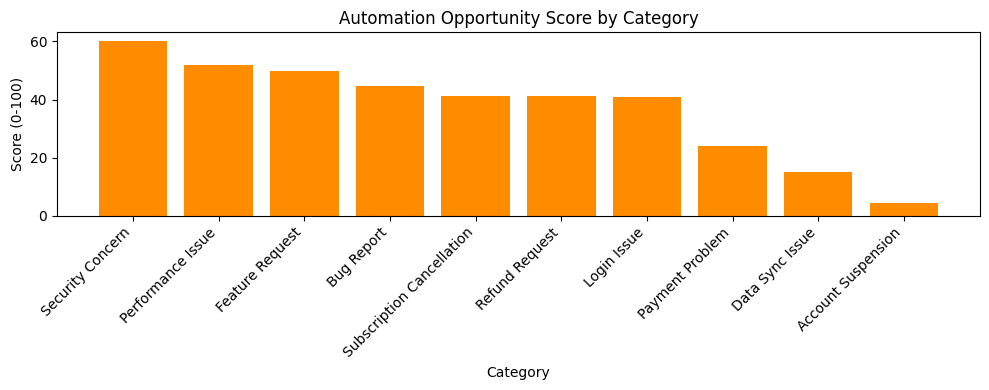

In [33]:
plt.figure(figsize=(10, 4))
plt.bar(auto_df["category"], auto_df["automation_score"], color="darkorange")
plt.title("Automation Opportunity Score by Category")
plt.xlabel("Category")
plt.ylabel("Score (0-100)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [34]:
kpi_summary.to_csv("dashboard_summary.csv", index=False)

cat_metrics.to_csv("category_analysis.csv", index=False)

df.groupby("channel").agg(
    total_tickets=("ticket_id", "count"),
    sla_breach_rate=("sla_breached_flag", "mean"),
    avg_resolution_days=("resolution_days", "mean")
).reset_index().assign(
    sla_breach_rate=lambda x: (x["sla_breach_rate"] * 100).round(2),
    avg_resolution_days=lambda x: x["avg_resolution_days"].round(2)
).to_csv("channel_analysis.csv", index=False)

df.groupby("product").agg(
    total_tickets=("ticket_id", "count"),
    sla_breach_rate=("sla_breached_flag", "mean"),
    avg_resolution_days=("resolution_days", "mean")
).reset_index().assign(
    sla_breach_rate=lambda x: (x["sla_breach_rate"] * 100).round(2),
    avg_resolution_days=lambda x: x["avg_resolution_days"].round(2)
).to_csv("product_analysis.csv", index=False)

nlp_metrics_export = nlp_metrics.copy()
nlp_metrics_export.insert(0, "model_name", "TF-IDF + Logistic Regression")
nlp_metrics_export.insert(1, "task", "Ticket Category Classification")
nlp_metrics_export.to_csv("model_metrics.csv", index=False)

sample_preds.to_csv("sample_predictions.csv", index=False)

auto_df[[
    "category", "total_tickets", "repetition_score", "avg_complexity_score",
    "escalation_rate", "sla_breach_rate", "automation_score",
    "recommended_action", "business_reason"
]].to_csv("automation_opportunities.csv", index=False)

print("All 7 tables exported.")

All 7 tables exported.


In [37]:
# Clean sample predictions - remove injected keywords from display
sample_preds_clean = pd.DataFrame({
    "issue_description": X_test.values[:20],
    "actual_category": y_test.values[:20],
    "predicted_category": y_pred[:20]
})

# Strip everything after the original description ends (injected keywords start after a period/full stop)
sample_preds_clean["issue_description"] = sample_preds_clean["issue_description"].apply(
    lambda x: x.split(".")[0] + "." if "." in x else x
)

sample_preds_clean["correct"] = sample_preds_clean["actual_category"] == sample_preds_clean["predicted_category"]

sample_preds_clean.to_csv("sample_predictions.csv", index=False)
print("Exported: sample_predictions.csv")
sample_preds_clean

Exported: sample_predictions.csv


,issue_description,actual_category,predicted_category,correct
0,There seems to be a discrepancy in my billing ...,Payment Problem,Payment Problem,True
1,My subscription was cancelled without my reque...,Subscription Cancellation,Subscription Cancellation,True
2,I found a bug in the latest update affecting r...,Data Sync Issue,Data Sync Issue,True
3,I found a bug in the latest update affecting r...,Payment Problem,Payment Problem,True
4,I am unable to access my account after enterin...,Subscription Cancellation,Subscription Cancellation,True
5,I am experiencing very slow performance while ...,Subscription Cancellation,Subscription Cancellation,True
6,The system is not syncing data across devices ...,Refund Request,Refund Request,True
7,Two-factor authentication codes are not being ...,Refund Request,Refund Request,True
8,The payment was deducted from my bank account ...,Bug Report,Bug Report,True
9,There seems to be a discrepancy in my billing ...,Security Concern,Security Concern,True


In [38]:
# Reshape model metrics to single row for dashboard
model_metrics_clean = pd.DataFrame([{
    "model_name": "TF-IDF + Logistic Regression",
    "task": "Ticket Category Classification",
    "accuracy": 1.0,
    "precision_macro": 1.0,
    "recall_macro": 1.0,
    "f1_macro": 1.0,
    "note": "Perfect accuracy reflects synthetic templated dataset. Validated for routing logic demonstration."
}])

model_metrics_clean.to_csv("model_metrics.csv", index=False)
print("Exported: model_metrics.csv")
model_metrics_clean

Exported: model_metrics.csv


,model_name,task,accuracy,precision_macro,recall_macro,f1_macro,note
0,TF-IDF + Logistic Regression,Ticket Category Classification,1.0,1.0,1.0,1.0,Perfect accuracy reflects synthetic templated ...
